# CSE499B weekly comparison: inpainting + image generation

This notebook merges the main metrics visible in this week's notebooks and builds clean tables and plots.

## Important note
Directly comparing **inpainting** and **full image generation** by FID alone is **not fully fair**, because:
- the tasks are different
- the data splits are different
- the conditioning is different
- the inpainting runs used a smaller subset with masks
- the generation run used full-noise synthesis on a much larger CelebA split

So this notebook gives:
1. an **inpainting-only comparison**
2. a **weekly all-work summary table**
3. separate loss curves for inpainting and generation


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weekly_metrics = [{'task': 'Inpainting', 'model': 'Old baseline inpainting', 'short_name': 'old_inpaint', 'dataset': 'CelebA subset (10k train / 1k val / 1k test)', 'params_million': 53.99, 'macs_billion': 9.8565, 'fid': 135.4702, 'sec_per_img': 0.23057, 'final_train_loss': 0.020338, 'final_val_loss': 0.018564, 'used_ema': True}, {'task': 'Inpainting', 'model': 'Variant A inpainting', 'short_name': 'varA_inpaint', 'dataset': 'CelebA subset (10k train / 1k val / 1k test)', 'params_million': 5.2029, 'macs_billion': 1.613, 'fid': 103.731, 'sec_per_img': 0.087055, 'final_train_loss': 0.02361, 'final_val_loss': 0.022101, 'used_ema': True}, {'task': 'Inpainting', 'model': 'Variant B inpainting', 'short_name': 'varB_inpaint', 'dataset': 'CelebA subset (10k train / 1k val / 1k test)', 'params_million': 1.7287, 'macs_billion': 0.4885, 'fid': 91.7524, 'sec_per_img': 0.048839, 'final_train_loss': 0.031713, 'final_val_loss': 0.029256, 'used_ema': True}, {'task': 'Image generation', 'model': 'Old baseline generation', 'short_name': 'old_gen', 'dataset': 'CelebA full split (162,770 train / 19,962 test)', 'params_million': 53.9877, 'macs_billion': 9.8471, 'fid': 32.6778, 'sec_per_img': 0.244631, 'final_train_loss': 0.016363, 'final_val_loss': None, 'used_ema': False}]
df = pd.DataFrame(weekly_metrics)
df


,task,model,short_name,dataset,params_million,macs_billion,fid,sec_per_img,final_train_loss,final_val_loss,used_ema
0,Inpainting,Old baseline inpainting,old_inpaint,CelebA subset (10k train / 1k val / 1k test),53.9900,9.8565,135.4702,0.230570,0.020338,0.018564,True
1,Inpainting,Variant A inpainting,varA_inpaint,CelebA subset (10k train / 1k val / 1k test),5.2029,1.6130,103.7310,0.087055,0.023610,0.022101,True
2,Inpainting,Variant B inpainting,varB_inpaint,CelebA subset (10k train / 1k val / 1k test),1.7287,0.4885,91.7524,0.048839,0.031713,0.029256,True
3,Image generation,Old baseline generation,old_gen,"CelebA full split (162,770 train / 19,962 test)",53.9877,9.8471,32.6778,0.244631,0.016363,NaN,False


In [2]:

# Add reductions vs old inpainting baseline for the inpainting-only table
df_inpaint = df[df["task"] == "Inpainting"].copy().reset_index(drop=True)
base_params = float(df_inpaint.loc[df_inpaint["short_name"] == "old_inpaint", "params_million"].iloc[0])
base_macs = float(df_inpaint.loc[df_inpaint["short_name"] == "old_inpaint", "macs_billion"].iloc[0])

df_inpaint["param_reduction_%_vs_old"] = ((base_params - df_inpaint["params_million"]) / base_params * 100).round(2)
df_inpaint["mac_reduction_%_vs_old"] = ((base_macs - df_inpaint["macs_billion"]) / base_macs * 100).round(2)

df_inpaint = df_inpaint[[
    "model", "params_million", "macs_billion", "fid", "sec_per_img",
    "final_train_loss", "final_val_loss", "param_reduction_%_vs_old", "mac_reduction_%_vs_old"
]]

df_inpaint


,model,params_million,macs_billion,fid,sec_per_img,final_train_loss,final_val_loss,param_reduction_%_vs_old,mac_reduction_%_vs_old
0,Old baseline inpainting,53.9900,9.8565,135.4702,0.230570,0.020338,0.018564,0.00,0.00
1,Variant A inpainting,5.2029,1.6130,103.7310,0.087055,0.023610,0.022101,90.36,83.64
2,Variant B inpainting,1.7287,0.4885,91.7524,0.048839,0.031713,0.029256,96.80,95.04


In [3]:

# Weekly summary table with a simple efficiency score for the inpainting runs only
# Lower is better for FID, params, MACs, and sec/img.
rank_cols = ["fid", "params_million", "macs_billion", "sec_per_img"]
tmp = df[df["task"] == "Inpainting"].copy()

for c in rank_cols:
    tmp[f"rank_{c}"] = tmp[c].rank(method="min", ascending=True)

tmp["efficiency_score"] = tmp[[f"rank_{c}" for c in rank_cols]].sum(axis=1)
tmp = tmp.sort_values(["efficiency_score", "fid", "sec_per_img"]).reset_index(drop=True)

tmp[["model", "fid", "params_million", "macs_billion", "sec_per_img", "efficiency_score"]]


,model,fid,params_million,macs_billion,sec_per_img,efficiency_score
0,Variant B inpainting,91.7524,1.7287,0.4885,0.048839,4.0
1,Variant A inpainting,103.7310,5.2029,1.6130,0.087055,8.0
2,Old baseline inpainting,135.4702,53.9900,9.8565,0.230570,12.0


In [4]:

# Save clean CSV tables
df.to_csv("weekly_all_work_summary.csv", index=False)
df_inpaint.to_csv("weekly_inpainting_comparison.csv", index=False)
print("Saved: weekly_all_work_summary.csv")
print("Saved: weekly_inpainting_comparison.csv")


Saved: weekly_all_work_summary.csv
Saved: weekly_inpainting_comparison.csv


## Loss curves reconstructed from the notebook outputs

In [5]:

inpaint_old = [(1, 0.135864, 0.813018), (2, 0.041759, 0.252464), (3, 0.03443, 0.107411), (4, 0.030658, 0.067811), (5, 0.028223, 0.055682), (6, 0.026421, 0.043824), (7, 0.025139, 0.038354), (8, 0.024165, 0.034182), (9, 0.023532, 0.031267), (10, 0.023136, 0.028357), (11, 0.022853, 0.026964), (12, 0.022532, 0.025345), (13, 0.022255, 0.024306), (14, 0.022036, 0.023129), (15, 0.021812, 0.022482), (16, 0.021567, 0.021537), (17, 0.02118, 0.021095), (18, 0.022545, 0.019972), (19, 0.019671, 0.0214), (20, 0.020338, 0.018564)]
inpaint_a = [(1, 0.188596, 0.997998), (2, 0.056583, 0.380775), (3, 0.045187, 0.166682), (4, 0.040179, 0.092561), (5, 0.036933, 0.074549), (6, 0.034284, 0.057527), (7, 0.032309, 0.048434), (8, 0.030813, 0.042449), (9, 0.029795, 0.037977), (10, 0.029042, 0.03474), (11, 0.028337, 0.03202), (12, 0.027852, 0.030752), (13, 0.027435, 0.02881), (14, 0.027013, 0.027442), (15, 0.026598, 0.026786), (16, 0.026118, 0.025277), (17, 0.025772, 0.024888), (18, 0.026235, 0.023918), (19, 0.023297, 0.025322), (20, 0.02361, 0.022101)]
inpaint_b = [(1, 0.370209, 1.378601), (2, 0.088878, 0.717792), (3, 0.072118, 0.348943), (4, 0.062806, 0.19864), (5, 0.056235, 0.138552), (6, 0.051273, 0.097194), (7, 0.047446, 0.074597), (8, 0.044366, 0.060235), (9, 0.042025, 0.051792), (10, 0.040476, 0.045773), (11, 0.039157, 0.042049), (12, 0.038043, 0.039299), (13, 0.037193, 0.036938), (14, 0.036443, 0.034765), (15, 0.035715, 0.033616), (16, 0.03503, 0.032356), (17, 0.034294, 0.031313), (18, 0.036035, 0.032061), (19, 0.031428, 0.035494), (20, 0.031713, 0.029256)]
gen_base = [(1, 0.030279), (2, 0.019503), (3, 0.018439), (4, 0.018204), (5, 0.017735), (6, 0.017462), (7, 0.017326), (8, 0.017126), (9, 0.01702), (10, 0.016932), (11, 0.0168), (12, 0.016739), (13, 0.01668), (14, 0.016616), (15, 0.016564), (16, 0.01653), (17, 0.016487), (18, 0.016457), (19, 0.016432), (20, 0.016407), (21, 0.016391), (22, 0.016379), (23, 0.016368), (24, 0.016359), (25, 0.016353), (26, 0.016349), (27, 0.016306), (28, 0.016363)]

df_old = pd.DataFrame(inpaint_old, columns=["epoch", "train_loss", "val_loss"])
df_a = pd.DataFrame(inpaint_a, columns=["epoch", "train_loss", "val_loss"])
df_b = pd.DataFrame(inpaint_b, columns=["epoch", "train_loss", "val_loss"])
df_gen = pd.DataFrame(gen_base, columns=["epoch", "train_loss"])


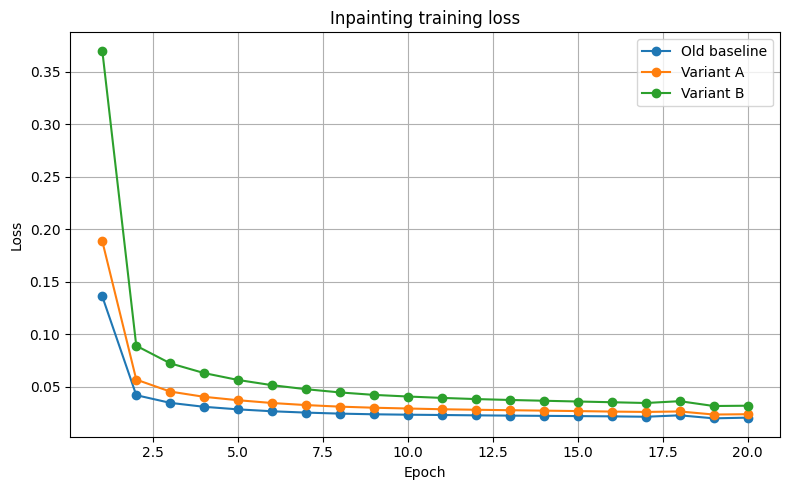

In [6]:

# Inpainting training loss
plt.figure(figsize=(8, 5))
plt.plot(df_old["epoch"], df_old["train_loss"], marker="o", label="Old baseline")
plt.plot(df_a["epoch"], df_a["train_loss"], marker="o", label="Variant A")
plt.plot(df_b["epoch"], df_b["train_loss"], marker="o", label="Variant B")
plt.title("Inpainting training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


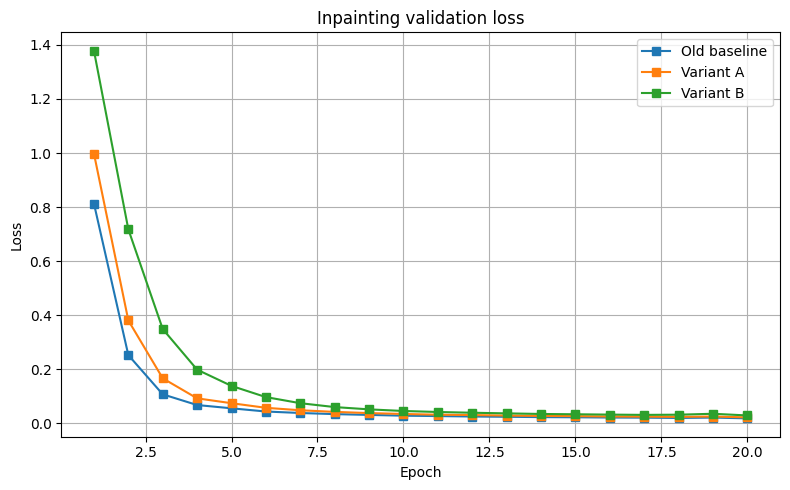

In [7]:

# Inpainting validation loss
plt.figure(figsize=(8, 5))
plt.plot(df_old["epoch"], df_old["val_loss"], marker="s", label="Old baseline")
plt.plot(df_a["epoch"], df_a["val_loss"], marker="s", label="Variant A")
plt.plot(df_b["epoch"], df_b["val_loss"], marker="s", label="Variant B")
plt.title("Inpainting validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


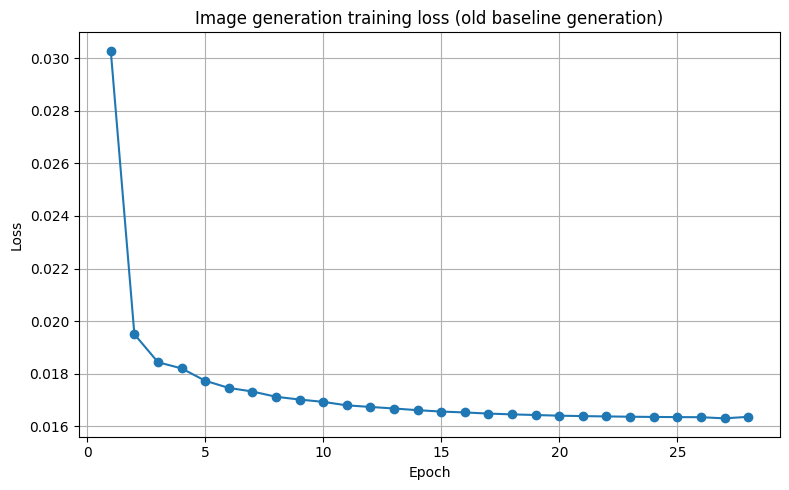

In [8]:

# Generation training loss
plt.figure(figsize=(8, 5))
plt.plot(df_gen["epoch"], df_gen["train_loss"], marker="o")
plt.title("Image generation training loss (old baseline generation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## Metric comparison plots

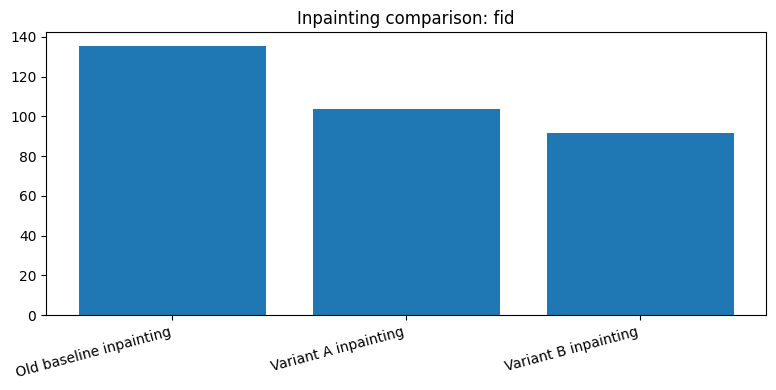

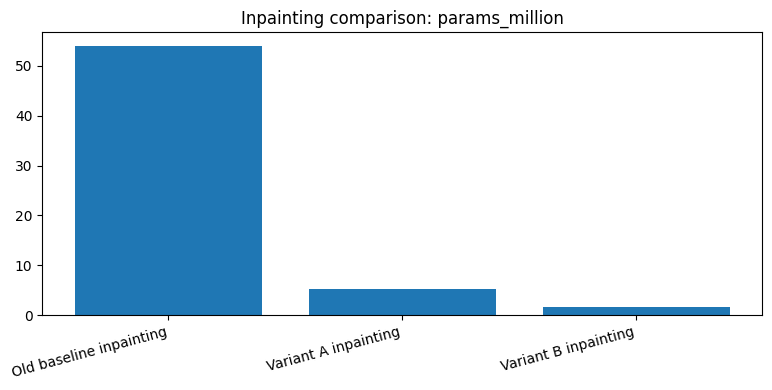

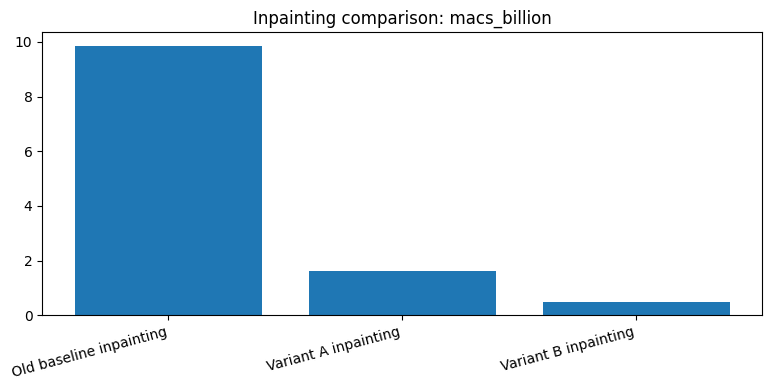

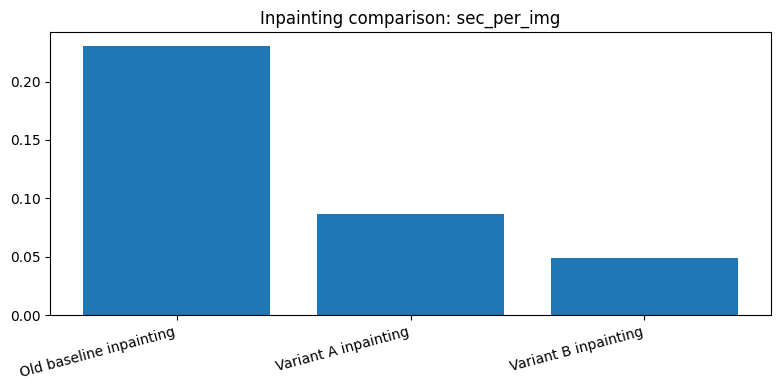

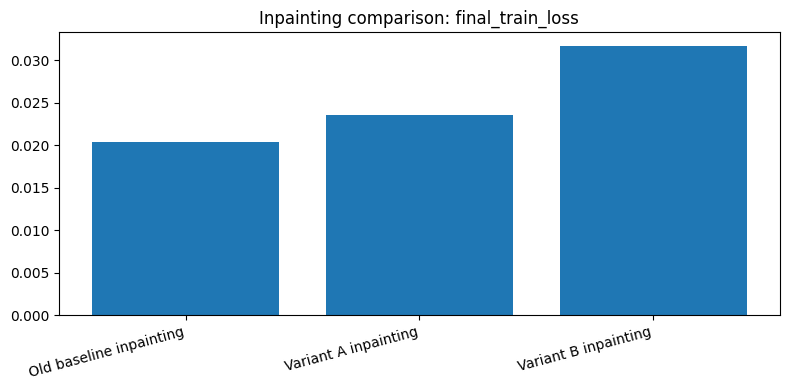

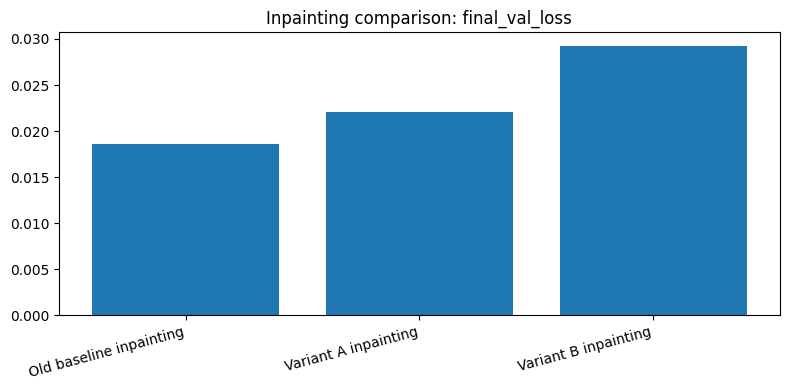

In [9]:

# Inpainting-only plots
plot_cols = ["fid", "params_million", "macs_billion", "sec_per_img", "final_train_loss", "final_val_loss"]
for col in plot_cols:
    plt.figure(figsize=(8, 4))
    plt.bar(df_inpaint["model"], df_inpaint[col])
    plt.title(f"Inpainting comparison: {col}")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


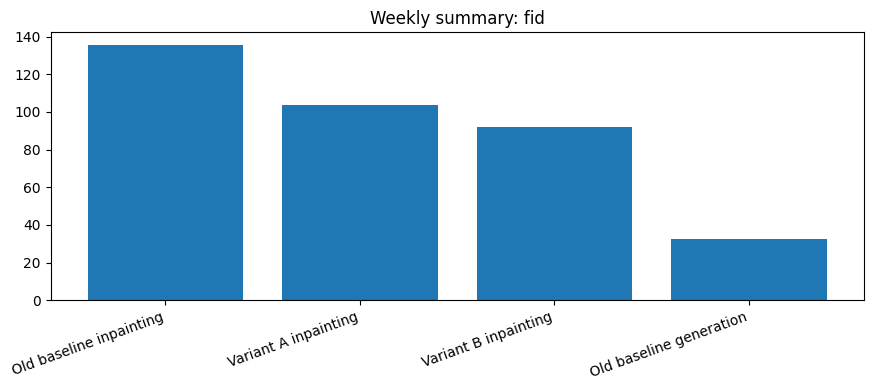

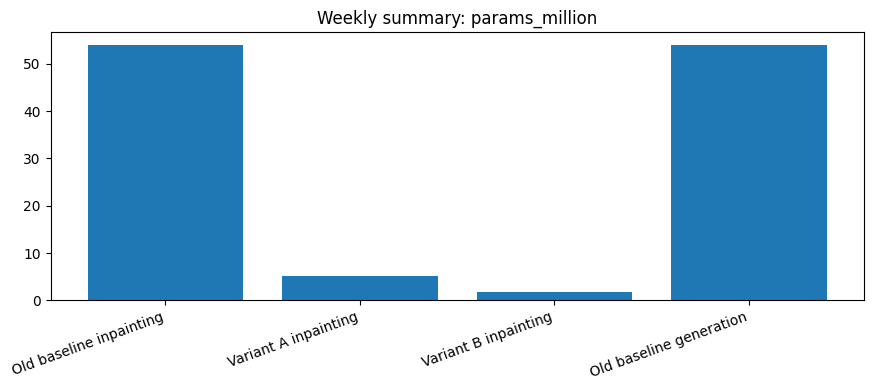

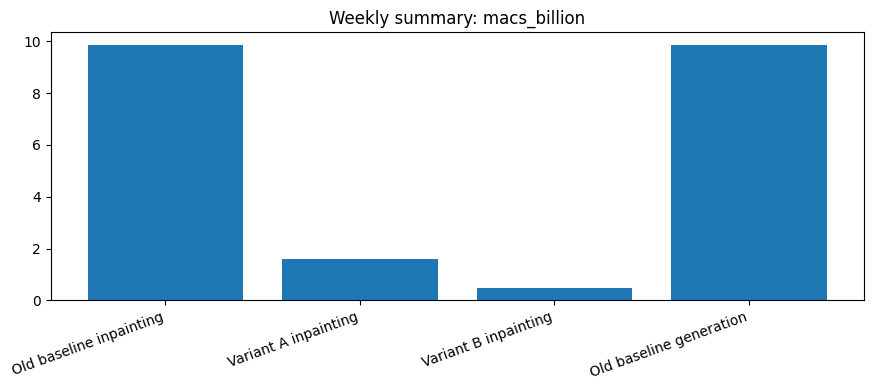

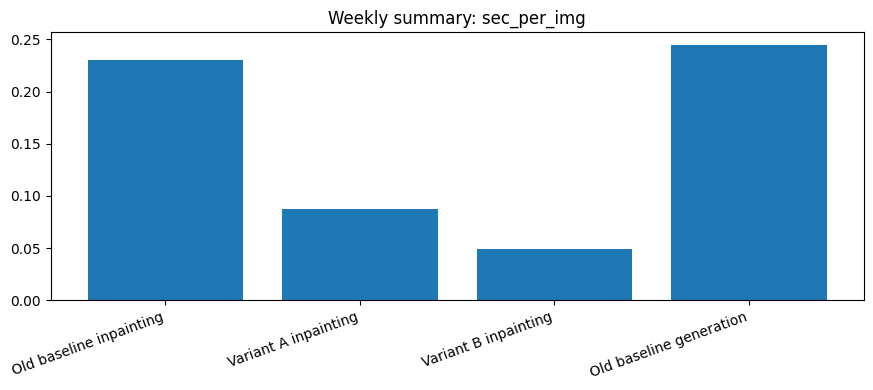

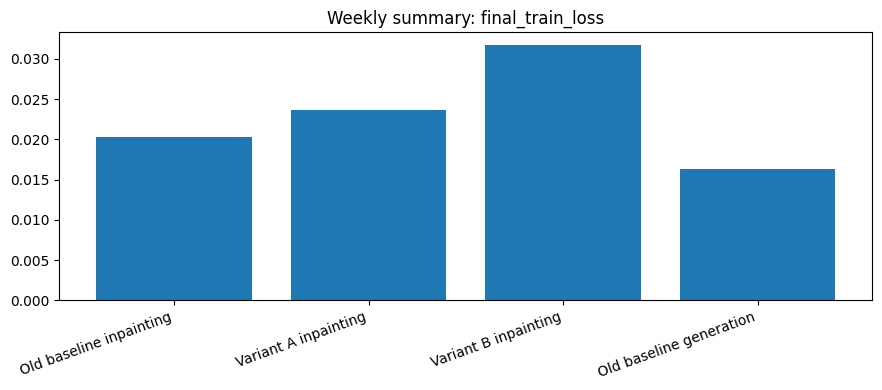

In [10]:

# Weekly all-work summary plot
plot_cols = ["fid", "params_million", "macs_billion", "sec_per_img", "final_train_loss"]
for col in plot_cols:
    plt.figure(figsize=(9, 4))
    plt.bar(df["model"], df[col])
    plt.title(f"Weekly summary: {col}")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


## Auto-generated takeaways

The code below prints short report-ready observations.


In [11]:

best_fid_inpaint = df_inpaint.sort_values("fid").iloc[0]
fastest_inpaint = df_inpaint.sort_values("sec_per_img").iloc[0]
smallest_inpaint = df_inpaint.sort_values("params_million").iloc[0]
lowest_val_inpaint = df_inpaint.sort_values("final_val_loss").iloc[0]

print("Inpainting takeaways:")
print(f"- Best inpainting FID: {best_fid_inpaint['model']} ({best_fid_inpaint['fid']})")
print(f"- Fastest inpainting model: {fastest_inpaint['model']} ({fastest_inpaint['sec_per_img']} sec/img)")
print(f"- Smallest inpainting model: {smallest_inpaint['model']} ({smallest_inpaint['params_million']}M params)")
print(f"- Lowest inpainting validation loss: {lowest_val_inpaint['model']} ({lowest_val_inpaint['final_val_loss']})")

print("\nWeekly summary takeaways:")
gen_row = df[df["task"] == "Image generation"].iloc[0]
print(f"- Full image generation baseline reached FID {gen_row['fid']} with {gen_row['params_million']}M params.")
print("- Do not claim that generation beat inpainting just from the lower FID, because the tasks and evaluation setups are different.")
print("- For the inpainting branch, Variant B is the strongest efficiency-focused result this week.")
print("- For the generation branch, the old baseline is the main completed full-noise result this week.")


Inpainting takeaways:
- Best inpainting FID: Variant B inpainting (91.7524)
- Fastest inpainting model: Variant B inpainting (0.048839 sec/img)
- Smallest inpainting model: Variant B inpainting (1.7287M params)
- Lowest inpainting validation loss: Old baseline inpainting (0.018564)

Weekly summary takeaways:
- Full image generation baseline reached FID 32.6778 with 53.9877M params.
- Do not claim that generation beat inpainting just from the lower FID, because the tasks and evaluation setups are different.
- For the inpainting branch, Variant B is the strongest efficiency-focused result this week.
- For the generation branch, the old baseline is the main completed full-noise result this week.
